<a href="https://colab.research.google.com/github/athfizh/PemMes26_05_Hafizh/blob/main/JS06/JS06-03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---


# **Klasifikasi 2 - Lab 3**


---

---


# **Langkah 1 - Import Library dan Buat Fungsi Plotting**


---

In [1]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC
from sklearn.datasets import make_blobs

In [2]:
# buat sebuah fungsi untuk menampilkan fitting data
def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none', edgecolors='k');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

---


# **Langkah 2 - Buat Data Dummy**


---

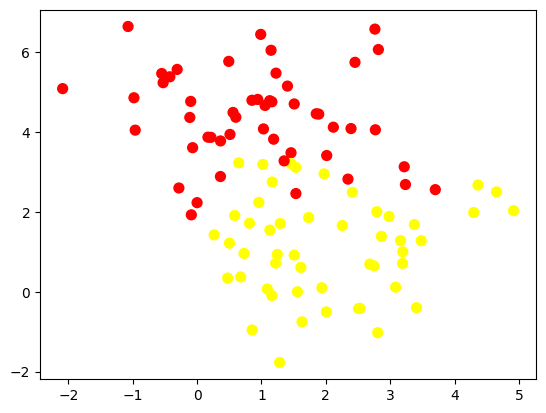

In [3]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.show()

> Dengan `cluster_std=1.2`, kedua kelas saling tumpang tindih sehingga tidak ada garis lurus yang bisa memisahkan semua titik dengan sempurna (kalau dicoba hard margin, akurasi training hanya sekitar 0,87). Karena itu dibutuhkan soft margin yang kelonggarannya diatur lewat parameter C.

---


# **Langkah 3 - Analisis Dampak Tunning**


---

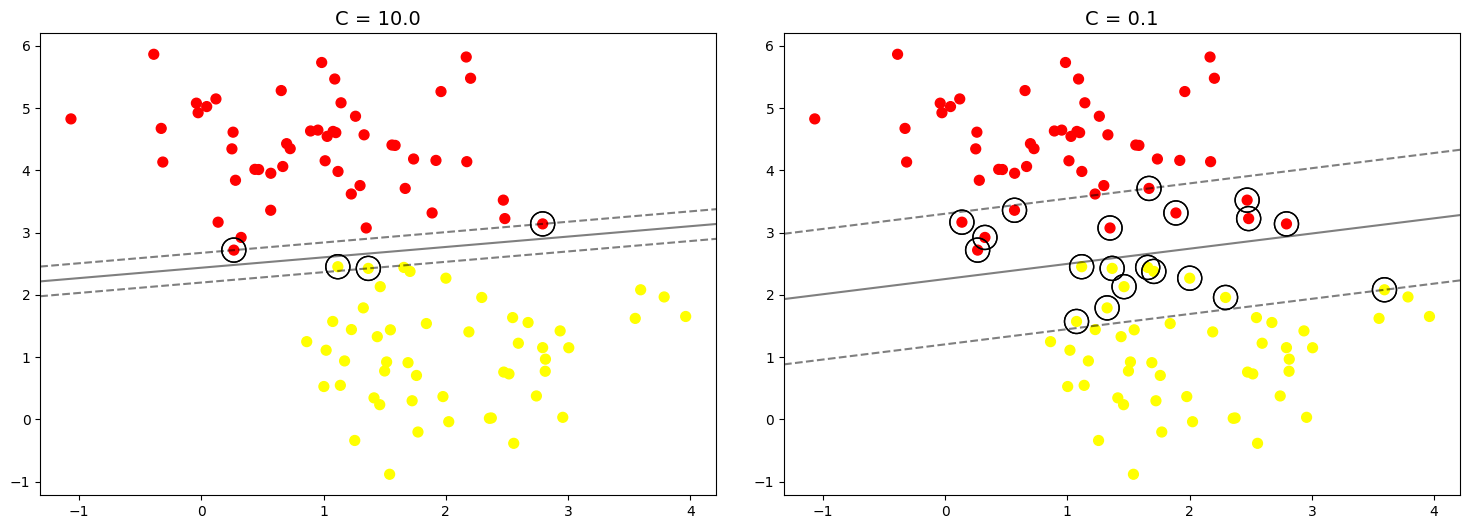

In [4]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [10.0, 0.1]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none', edgecolors='k');
    axi.set_title('C = {0:.1f}'.format(C), size=14)
plt.show()

In [5]:
# bandingkan jumlah support vector dan akurasi untuk tiap nilai C
for C in [10.0, 0.1]:
    model = SVC(kernel='linear', C=C).fit(X, y)
    print(f'C = {C:<5} | support vector = {len(model.support_vectors_):<3} | akurasi = {model.score(X, y):.2f}')

C = 10.0  | support vector = 4   | akurasi = 1.00
C = 0.1   | support vector = 20  | akurasi = 1.00


> Pada C = 10 margin terlihat sempit dan hanya ada 4 support vector, sedangkan pada C = 0,1 margin jauh lebih lebar dengan 20 support vector karena lebih banyak titik yang diizinkan masuk ke dalam margin. Akurasi training keduanya sama-sama 1,00, jadi yang berubah adalah kelonggaran margin, bukan akurasinya. C yang besar membuat model ketat dan berisiko overfitting, sedangkan C yang kecil membuat model longgar dan berisiko underfitting. Nilai C yang optimal berbeda untuk tiap dataset sehingga perlu dicari lewat cross-validation.